# Instant Policy - PoC
The aim of this notebook is to perform a "simple" proof of concept for the Instant Policy approach. The model will be trained with multiple simple planar trajectories and then evaluated against other simples and complex trajectories.

In [7]:
from src.trajectory_generator import TrajectoryGenerator
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def create_pseudo_demo(trajectory, noise_level=0.3):
    """Creates the Instant Policy pair: target and context (context is target with noise"""
    target = trajectory.astype(np.float32)
    context = target + np.random.normal(0, noise_level, target.shape)
    return context.astype(np.float32), target

In [12]:
def get_trajectory_types(n_points):
    """Devuelve la lista de generadores aleatorios parametrizados"""
    return [
        ("linear", lambda: TrajectoryGenerator.linear(n_points, 
            start=(np.random.uniform(-1, 1), np.random.uniform(-1, 1)), 
            angle=np.random.uniform(0, 360), 
            length=np.random.uniform(0.5, 2.0))),
        ("sinusoidal", lambda: TrajectoryGenerator.sinusoidal(n_points, 
            amp=np.random.uniform(0.1, 1.0), 
            freq=np.random.uniform(0.5, 3.0), 
            phase=np.random.uniform(0, 2 * np.pi))),
        ("circular", lambda: TrajectoryGenerator.circular(n_points, 
            radius=np.random.uniform(0.5, 2.0), 
            arc_ratio=np.random.uniform(0.5, 1.0), 
            start_angle=np.random.uniform(0, 360))),
        ("parabolic", lambda: TrajectoryGenerator.parabolic(n_points, 
            a=np.random.uniform(-2.0, 2.0), 
            h=np.random.uniform(-1.0, 1.0), 
            k=np.random.uniform(-1.0, 1.0))),
        ("exponential", lambda: TrajectoryGenerator.exponential(n_points, 
            a=np.random.uniform(0.5, 2.0), 
            b=np.random.uniform(-1.5, 1.5))),
        ("sigmoid", lambda: TrajectoryGenerator.sigmoid(n_points, 
            L=np.random.uniform(0.5, 2.0), 
            k=np.random.uniform(5, 15), 
            x0=np.random.uniform(0.5, 1.5))),
        ("staggered_step", lambda: TrajectoryGenerator.staggered_step(n_points, 
            n_steps=np.random.randint(2, 6), 
            step_height=np.random.uniform(0.2, 1.0))),
        ("spiral", lambda: TrajectoryGenerator.spiral(n_points, 
            b=np.random.uniform(0.05, 0.2), 
            theta_max=np.random.uniform(2 * np.pi, 6 * np.pi))),
        ("lemniscate", lambda: TrajectoryGenerator.lemniscate(n_points, 
            a=np.random.uniform(1.0, 2.5))),
        ("lissajous", lambda: TrajectoryGenerator.lissajous(n_points, 
            A=np.random.uniform(0.5, 2.0), 
            B=np.random.uniform(0.5, 2.0), 
            a=np.random.randint(1, 5), 
            b=np.random.randint(1, 5), 
            delta=np.random.uniform(0, np.pi)))
    ]

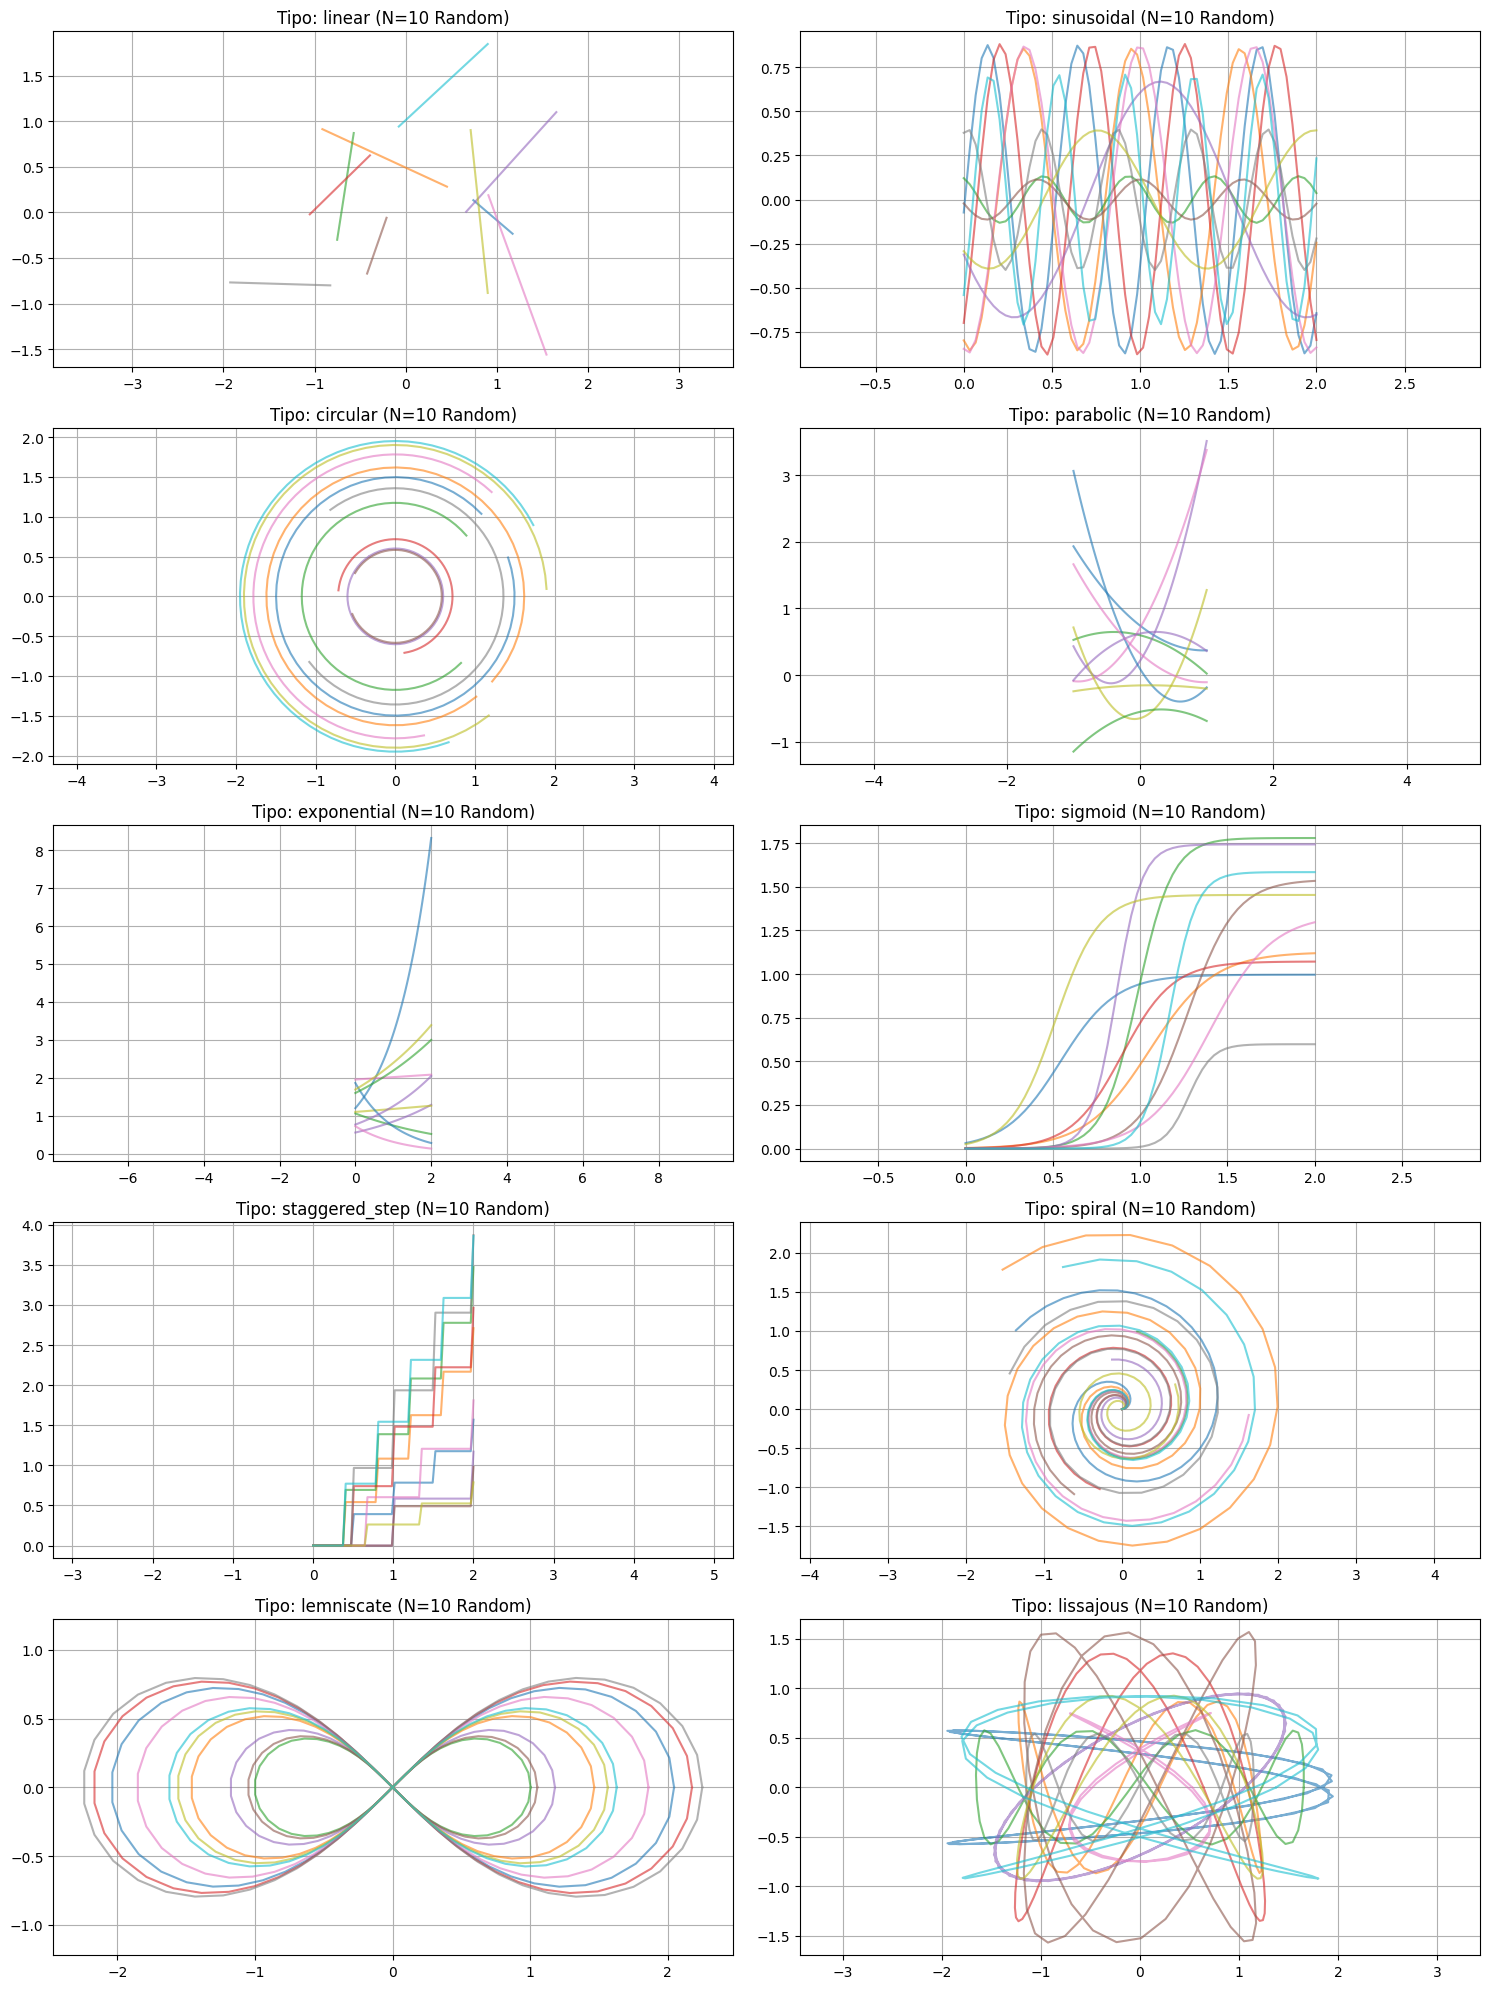

In [13]:
def plot_trajectory_samples(n_per_type=10, n_points=60):
    trajectory_types = get_trajectory_types(n_points)
    n_types = len(trajectory_types)
    
    # Preparamos una grilla de subplots (1 fila por tipo geométrico, 1 columna (pero metemos todas juntas o la superponemos))
    # En este caso vamos a graficar las 10 trayectorias del mismo tipo superpuestas en un mismo gráfico.
    fig, axes = plt.subplots(int(np.ceil(n_types/2)), 2, figsize=(15, 20))
    axes = axes.flatten()
    for idx, (name, gen_func) in enumerate(trajectory_types):
        ax = axes[idx]
        ax.set_title(f"Tipo: {name} (N={n_per_type} Random)")
        
        # Generar las 10 trayectorias aleatorias para este tipo y plotearlas en el mismo eje
        for _ in range(n_per_type):
            traj = gen_func()  # llamada al lambda, genera la variable aleatoria
            ax.plot(traj[:, 0], traj[:, 1], alpha=0.6, linewidth=1.5)
            
        ax.set_aspect('equal', 'datalim')
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()
# Ejecución de prueba
if __name__ == "__main__":
    plot_trajectory_samples(n_per_type=10)

In [14]:
def orchestrator(file_name, n_per_type=100, n_points=100):
    """Orquestador principal para generar y guardar el dataset."""
    
    with h5py.File(file_name, 'w') as f:
        data_group = f.create_group("data")
        demo_idx = 0
        
        # Definición de tipos y rangos de parámetros aleatorios
        trajectory_types = get_trajectory_types(n_points=100)

        for name, gen_func in trajectory_types:
            print(f"Generando {n_per_type} ejemplos de tipo: {name}...")
            for _ in range(n_per_type):
                # 1. Generar la forma geométrica
                traj = gen_func()
                
                # 2. Crear el par de pseudo-demonstración
                context, target = create_pseudo_demo(traj)
                
                # 3. Guardar en HDF5 con estructura de Robomimic
                demo_grp = data_group.create_group(f"demo_{demo_idx}")
                demo_grp.create_dataset("context", data=context)
                demo_grp.create_dataset("target", data=target)
                
                # Metadatos para facilitar el filtrado posterior
                demo_grp.attrs["type"] = name
                demo_grp.attrs["num_samples"] = n_points
                
                demo_idx += 1
        
        # Atributo global del dataset
        f.attrs["total_demos"] = demo_idx

    print(f"\n¡Éxito! Dataset guardado en '{file_name}' con {demo_idx} demostraciones totales.")

In [ ]:
FILENAME = "dataset_instant_policy_2d.h5"
orchestrator(FILENAME, n_per_type=150, n_points=100)

Generando 150 ejemplos de tipo: linear...
Generando 150 ejemplos de tipo: sinusoidal...
Generando 150 ejemplos de tipo: circular...
Generando 150 ejemplos de tipo: parabolic...
Generando 150 ejemplos de tipo: exponential...
Generando 150 ejemplos de tipo: sigmoid...
Generando 150 ejemplos de tipo: staggered_step...
Generando 150 ejemplos de tipo: spiral...
Generando 150 ejemplos de tipo: lemniscate...
Generando 150 ejemplos de tipo: lissajous...

¡Éxito! Dataset guardado en 'dataset_instant_policy_2d.h5' con 1500 demostraciones totales.


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_22788\2859700421.py:4: DeprecationWarning: This function is deprecated. Please call randint(0, 1500 + 1) instead
  d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)


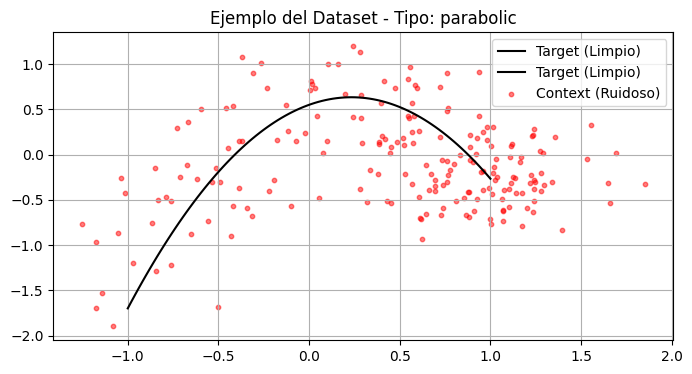

In [46]:
# Prueba rápida de visualización
with h5py.File(FILENAME, 'r') as f:
    n = f.attrs['total_demos']
    d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)
    plt.figure(figsize=(8,4))
    plt.plot(d['target'][:,0], d['target'][:,1], 'k-', label='Target (Limpio)')
    plt.scatter(d['context'][:,0], d['context'][:,1], c='r', alpha=0.5, s=10, label='Context (Ruidoso)')
    plt.title(f"Ejemplo del Dataset - Tipo: {d.attrs['type']}")
    plt.legend()
    plt.grid(True)
    plt.show()